# Notebook 3: Hydrological Analysis

## Objective

Hydrological characteristics strongly influence landslide susceptibility by controlling surface runoff, erosion, and soil saturation.

This notebook derives hydrological parameters from the clipped DEM, including:

- Flow Direction
- Flow Accumulation
- Stream Network
- Drainage Density

These outputs will be used as conditioning factors in the final landslide hazard zonation model.

In [8]:
# ============================================================
# Install Required Library
# ============================================================

!pip -q install pysheds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.3 MB/s eta 0:00:00


In [9]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio

from pysheds.grid import Grid

plt.rcParams["figure.figsize"] = (10,8)
plt.rcParams["font.size"] = 12

print("="*60)
print("Libraries imported successfully!")
print("="*60)

Libraries imported successfully!


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# ============================================================
# Define Project Paths
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/Landslide-Hazard-Zonation"

DEM_PATH = os.path.join(
    PROJECT_DIR,
    "outputs",
    "rasters",
    "idukki_dem.tif"
)

OUTPUT_RASTERS = os.path.join(PROJECT_DIR, "outputs", "rasters")
OUTPUT_FIGURES = os.path.join(PROJECT_DIR, "outputs", "figures")

print("DEM:")
print(DEM_PATH)

DEM:
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/idukki_dem.tif


In [12]:
# ============================================================
# Load DEM
# ============================================================

grid = Grid.from_raster(DEM_PATH)

dem = grid.read_raster(DEM_PATH)

print("="*60)
print("DEM loaded successfully!")
print("="*60)

print(dem.shape)

DEM loaded successfully!
(3902, 2823)


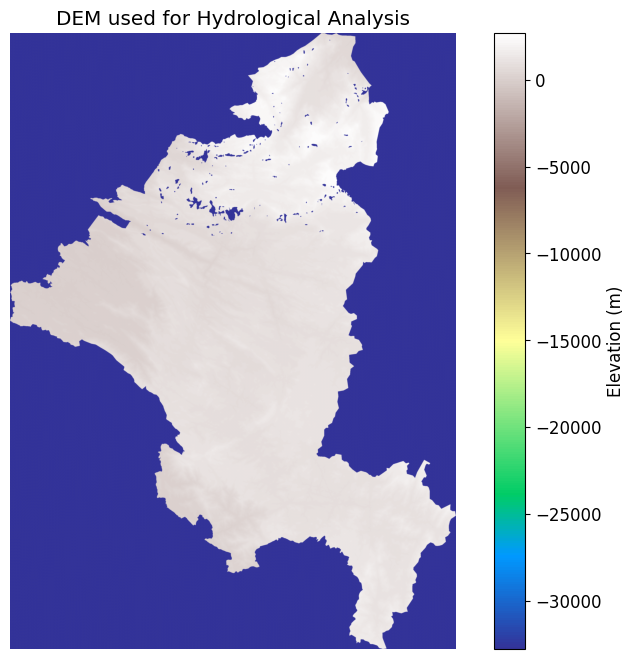

In [13]:
# ============================================================
# Display DEM
# ============================================================

plt.figure(figsize=(10,8))

plt.imshow(dem, cmap="terrain")

plt.colorbar(label="Elevation (m)")

plt.title("DEM used for Hydrological Analysis")

plt.axis("off")

plt.show()

## Hydrological Conditioning of the DEM

### Objective

Raw Digital Elevation Models often contain depressions (sinks) and flat areas that interrupt continuous water flow.

Before computing flow direction and flow accumulation, the DEM must be hydrologically conditioned.

The preprocessing consists of:

- Filling depressions
- Resolving flat areas
- Producing a hydrologically corrected DEM

This ensures that water can flow continuously across the terrain.

In [14]:
# ============================================================
# Fill Depressions
# ============================================================

filled_dem = grid.fill_depressions(dem)

print("=" * 60)
print("Depressions filled successfully!")
print("=" * 60)

Depressions filled successfully!


In [15]:
# ============================================================
# Resolve Flats
# ============================================================

inflated_dem = grid.resolve_flats(filled_dem)

print("=" * 60)
print("Flat areas resolved successfully!")
print("=" * 60)

Flat areas resolved successfully!


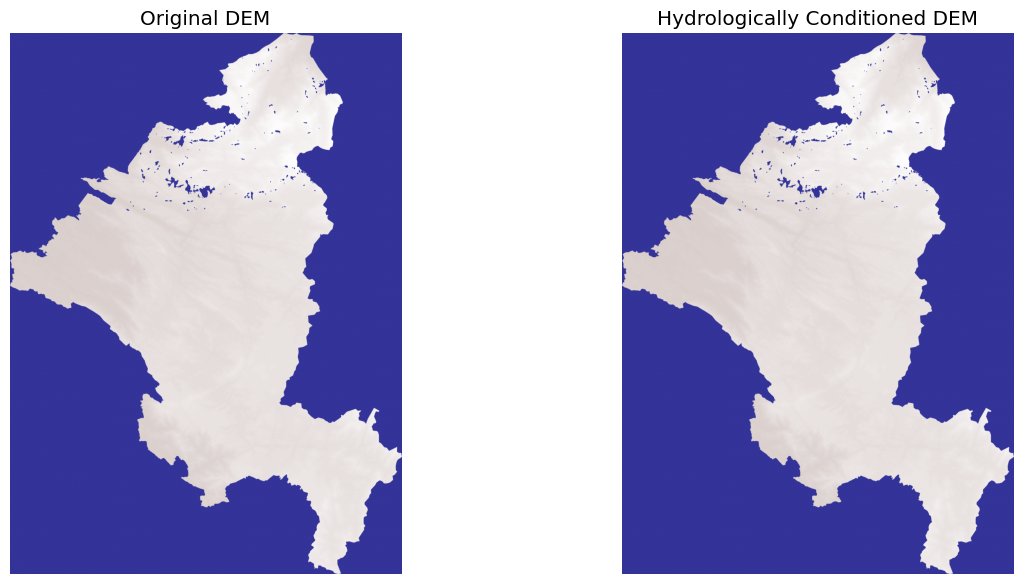

In [16]:
# ============================================================
# Compare Original and Corrected DEM
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(dem, cmap="terrain")
axes[0].set_title("Original DEM")
axes[0].axis("off")

axes[1].imshow(inflated_dem, cmap="terrain")
axes[1].set_title("Hydrologically Conditioned DEM")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Flow Direction (D8)

### Objective

Flow direction determines the direction in which water flows from each raster cell based on the steepest downslope neighbor.

The D8 (Deterministic Eight-node) algorithm is widely used in hydrological analysis and forms the basis for flow accumulation, stream extraction, and drainage network generation.

The resulting flow direction raster will be used to compute flow accumulation in the next step.

In [17]:
# ============================================================
# Calculate Flow Direction (D8)
# ============================================================

# D8 directional mapping used by PySheds
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)

flowdir = grid.flowdir(inflated_dem, dirmap=dirmap)

print("=" * 60)
print("Flow Direction calculated successfully!")
print("=" * 60)

print("Unique Flow Direction Values:")
print(np.unique(flowdir))

Flow Direction calculated successfully!
Unique Flow Direction Values:
[ -2  -1   0   1   2   4   8  16  32  64 128]


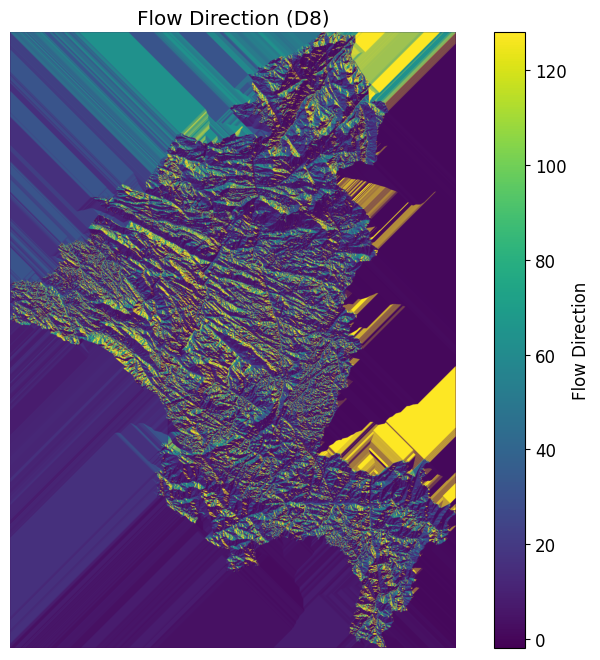

In [18]:
# ============================================================
# Plot Flow Direction
# ============================================================

plt.figure(figsize=(10, 8))

plt.imshow(flowdir, cmap="viridis")

plt.colorbar(label="Flow Direction")

plt.title("Flow Direction (D8)")

plt.axis("off")

plt.show()

In [19]:
# ============================================================
# Save Flow Direction Raster
# ============================================================

with rasterio.open(DEM_PATH) as src:
    profile = src.profile.copy()

# Remove problematic profile options
profile.pop("blockxsize", None)
profile.pop("blockysize", None)
profile.pop("tiled", None)

profile.update(
    dtype=rasterio.int16,
    count=1,
    compress="lzw"
)

FLOWDIR_PATH = os.path.join(
    OUTPUT_RASTERS,
    "flow_direction.tif"
)

with rasterio.open(FLOWDIR_PATH, "w", **profile) as dst:
    dst.write(flowdir.astype(np.int16), 1)

print("Flow direction raster saved successfully!")
print(FLOWDIR_PATH)

Flow direction raster saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/flow_direction.tif


## Flow Accumulation

### Objective

Flow accumulation represents the number of upstream raster cells contributing flow to each location.

Cells with high accumulation values indicate valleys and drainage channels, while low values correspond to ridges and hilltops.

Flow accumulation is fundamental for stream extraction and drainage density estimation.

In [20]:
# ============================================================
# Calculate Flow Accumulation
# ============================================================

flow_acc = grid.accumulation(flowdir, dirmap=dirmap)

print("=" * 60)
print("Flow Accumulation calculated successfully!")
print("=" * 60)

print("Maximum Flow Accumulation:", np.nanmax(flow_acc))

Flow Accumulation calculated successfully!
Maximum Flow Accumulation: 2652710.0


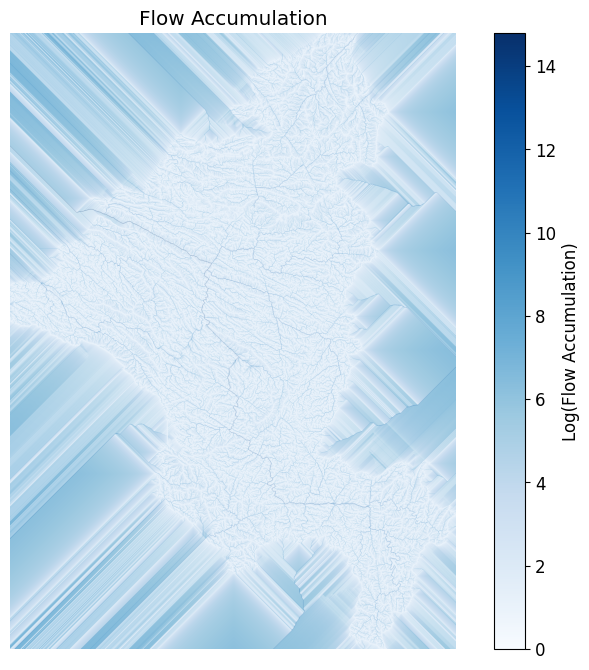

In [21]:
# ============================================================
# Plot Flow Accumulation
# ============================================================

plt.figure(figsize=(10,8))

plt.imshow(np.log1p(flow_acc), cmap="Blues")

plt.colorbar(label="Log(Flow Accumulation)")

plt.title("Flow Accumulation")

plt.axis("off")

plt.show()

In [22]:
# ============================================================
# Save Flow Accumulation Raster
# ============================================================

with rasterio.open(DEM_PATH) as src:
    profile = src.profile.copy()

profile.pop("blockxsize", None)
profile.pop("blockysize", None)
profile.pop("tiled", None)

profile.update(
    dtype=rasterio.float32,
    count=1,
    compress="lzw"
)

FLOWACC_PATH = os.path.join(
    OUTPUT_RASTERS,
    "flow_accumulation.tif"
)

with rasterio.open(FLOWACC_PATH, "w", **profile) as dst:
    dst.write(flow_acc.astype(np.float32), 1)

print("Flow accumulation raster saved successfully!")
print(FLOWACC_PATH)

Flow accumulation raster saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/flow_accumulation.tif


In [23]:
# ============================================================
# Extract Stream Network
# ============================================================

threshold = 1000

streams = flow_acc > threshold

print("=" * 60)
print("Stream network extracted successfully!")
print("=" * 60)
print("Threshold:", threshold)

Stream network extracted successfully!
Threshold: 1000


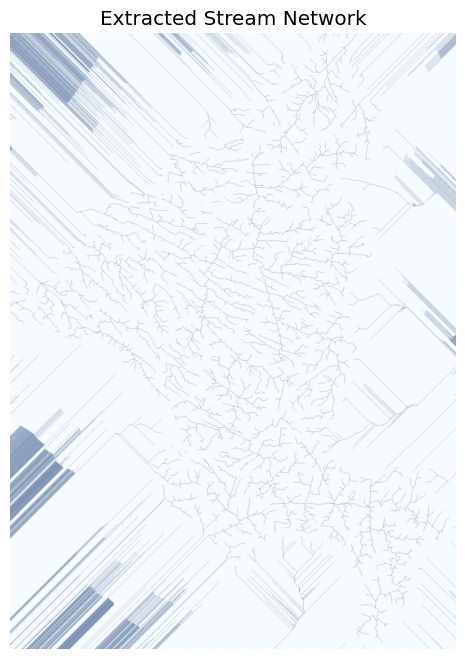

In [24]:
# ============================================================
# Plot Stream Network
# ============================================================

plt.figure(figsize=(10, 8))

plt.imshow(streams, cmap="Blues")

plt.title("Extracted Stream Network")

plt.axis("off")

plt.show()

In [26]:
# ============================================================
# Save Stream Raster
# ============================================================

with rasterio.open(DEM_PATH) as src:
    profile = src.profile.copy()

# Remove unnecessary keys
profile.pop("blockxsize", None)
profile.pop("blockysize", None)
profile.pop("tiled", None)

# Update profile
profile.update(
    dtype=rasterio.uint8,
    count=1,
    compress="lzw",
    nodata=0          # <-- Important fix
)

STREAM_PATH = os.path.join(
    OUTPUT_RASTERS,
    "stream_network.tif"
)

with rasterio.open(STREAM_PATH, "w", **profile) as dst:
    dst.write(streams.astype(np.uint8), 1)

print("Stream raster saved successfully!")
print(STREAM_PATH)

Stream raster saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/stream_network.tif


## 10. Drainage Density

Drainage density represents the concentration of streams within an area and is an important factor influencing landslide susceptibility. Higher drainage density generally indicates greater surface runoff concentration and increased erosion potential.

A moving window analysis is used to estimate the local density of the extracted stream network.

In [27]:
from scipy.ndimage import uniform_filter

print("Required package imported successfully!")

Required package imported successfully!


In [28]:
# ============================================================
# Calculate Drainage Density
# ============================================================

window_size = 101   # approximately 3 km window

drainage_density = uniform_filter(
    streams.astype(np.float32),
    size=window_size
)

print("=" * 60)
print("Drainage Density calculated successfully!")
print("=" * 60)

Drainage Density calculated successfully!


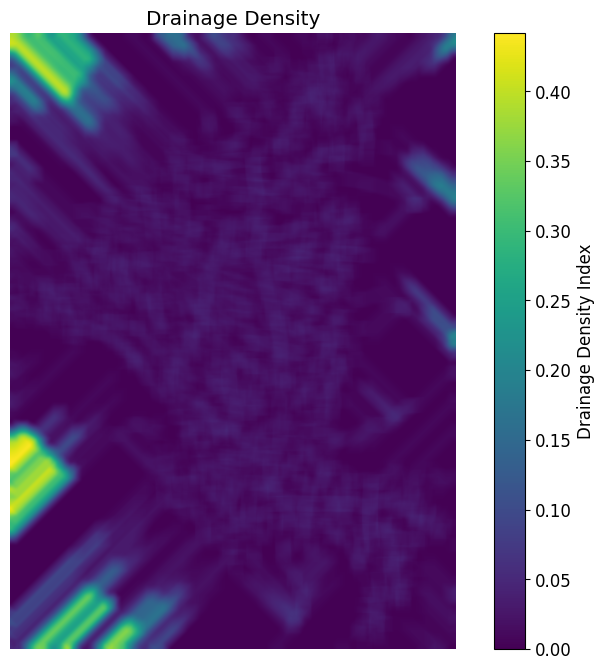

In [29]:
plt.figure(figsize=(10,8))

plt.imshow(drainage_density, cmap="viridis")

plt.colorbar(label="Drainage Density Index")

plt.title("Drainage Density")

plt.axis("off")

plt.show()

In [30]:
# ============================================================
# Save Drainage Density Raster
# ============================================================

with rasterio.open(DEM_PATH) as src:
    profile = src.profile.copy()

profile.pop("blockxsize", None)
profile.pop("blockysize", None)
profile.pop("tiled", None)
profile.pop("nodata", None)

profile.update(
    dtype=rasterio.float32,
    count=1,
    compress="lzw"
)

DRAINAGE_PATH = os.path.join(
    OUTPUT_RASTERS,
    "drainage_density.tif"
)

with rasterio.open(DRAINAGE_PATH, "w", **profile) as dst:
    dst.write(drainage_density.astype(np.float32), 1)

print("Drainage density raster saved successfully!")
print(DRAINAGE_PATH)

Drainage density raster saved successfully!
/content/drive/MyDrive/Landslide-Hazard-Zonation/outputs/rasters/drainage_density.tif


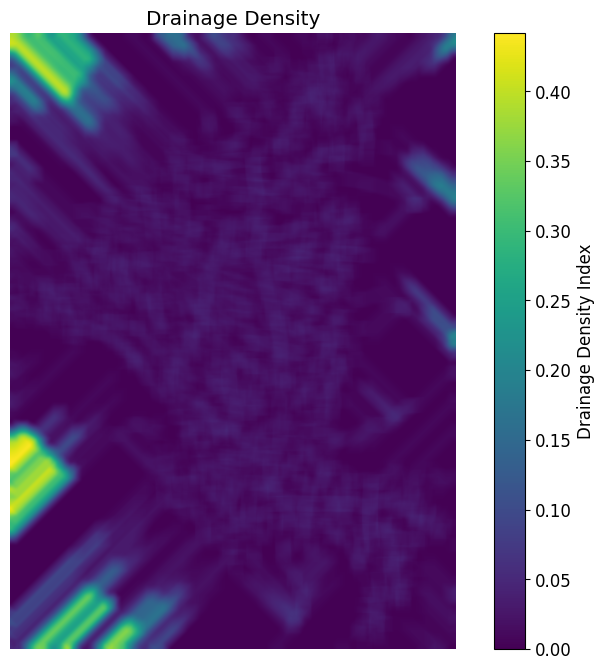

Drainage density map saved successfully!


In [31]:
plt.figure(figsize=(10,8))

plt.imshow(drainage_density, cmap="viridis")

plt.colorbar(label="Drainage Density Index")

plt.title("Drainage Density")

plt.axis("off")

plt.savefig(
    os.path.join(
        OUTPUT_FIGURES,
        "idukki_drainage_density_map.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Drainage density map saved successfully!")

In [32]:
print("=" * 60)
print("NOTEBOOK 3 COMPLETED")
print("=" * 60)

print("\nOutputs generated:")
print("✓ flow_direction.tif")
print("✓ flow_accumulation.tif")
print("✓ stream_network.tif")
print("✓ drainage_density.tif")
print("✓ idukki_drainage_density_map.png")

print("\nNotebook 3 processing complete.")

NOTEBOOK 3 COMPLETED

Outputs generated:
✓ flow_direction.tif
✓ flow_accumulation.tif
✓ stream_network.tif
✓ drainage_density.tif
✓ idukki_drainage_density_map.png

Notebook 3 processing complete.
